# Pelatihan Model YOLO11n untuk VNetra (Dataset Manual Kaggle)

Notebook ini dikhususkan untuk melakukan training YOLO11n menggunakan dataset yang **DIUPLOAD SECARA MANUAL** (via tombol Add Data) di Kaggle.

Ini sangat berguna jika Anda tidak ingin mengunduh ulang gambar dari Roboflow dan menunggu proses *merging* yang lama setiap kali memulai ulang *notebook*.

**Syarat Wajib Sebelum Menekan Run All:**
1. Klik tombol **Add Data** di kanan atas Kaggle.
2. Pilih tab **Your Work** (atau Datasets/Notebooks).
3. Tambahkan Dataset Anda yang sebelumnya sudah di-zip atau dipublikasikan.
4. Pastikan di dalam folder dataset tersebut terdapat file `data.yaml`.


In [1]:
!pip install -q albumentations
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.3 MB/s eta 0:00:00


## 1. Menyiapkan Dataset Secara Internal

Script ini akan mencari file `data.yaml` di dalam folder input Kaggle Anda secara otomatis, lalu menyalin seluruh isinya ke directory kerja lokal agar mempercepat proses pembacaan data oleh YOLO.

In [2]:
import os
import shutil
import yaml

print("🔍 Memindai seluruh folder /kaggle/input/ secara otomatis...")
found_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        found_path = root
        break

if found_path:
    print(f"🎯 BINGO! Dataset asli Anda ngumpet di: {found_path}")
    
    master_dir = '/kaggle/working/vnetra_master_dataset'
    
    # Hapus jika sudah ada sisa sebelumnya
    if os.path.exists(master_dir):
        shutil.rmtree(master_dir)
        
    print("⏳ Menyalin ke folder kerja (tunggu beberapa belas detik)...")
    shutil.copytree(found_path, master_dir)
    print("✅ Salin Dataset Selesai!\n")
    
    # Mengekstrak master_classes dan MEMPERBAIKI path direktori di data.yaml
    with open(f'{master_dir}/data.yaml', 'r') as f:
        yaml_data = yaml.safe_load(f)
        
    master_classes = yaml_data.get('names', [])
    print(f"📌 Ditemukan {len(master_classes)} kelas di data.yaml:")
    print(master_classes)
    
    # Menimpa (overwrite) path bawaan yang rusak/salah dari komputer asal
    yaml_data['path'] = master_dir
    yaml_data['train'] = 'train/images'
    yaml_data['val'] = 'valid/images'
    # Beberapa dataset menyebut validation sebagai 'val/images' atau 'valid/images'
    # Pastikan foldernya benar
    if os.path.exists(f'{master_dir}/val'):
        yaml_data['val'] = 'val/images'
    yaml_data['test'] = 'test/images'
    
    with open(f'{master_dir}/data.yaml', 'w') as f:
        yaml.safe_dump(yaml_data, f, sort_keys=False)
        
    print("✅ File data.yaml berhasil diperbarui dengan path absolut Kaggle yang benar!")
else:
    print("❌ Waduh, file data.yaml sama sekali tidak ditemukan di dalam /kaggle/input/!")
    print("Pastikan Anda sudah menekan 'Add Data' dan datasetnya benar-benar ada.")


🔍 Memindai seluruh folder /kaggle/input/ secara otomatis...
🎯 BINGO! Dataset asli Anda ngumpet di: /kaggle/input/datasets/aanandiyanasandi/vnetra-master-dataset-14-3-13415
⏳ Menyalin ke folder kerja (tunggu beberapa belas detik)...
✅ Salin Dataset Selesai!

📌 Ditemukan 14 kelas di data.yaml:
['person', 'car', 'motorcycle', 'bus', 'pole', 'tactile_paving_straight', 'tactile_paving_turn', 'tactile_paving_3way', 'tactile_paving_4way', 'tactile_paving_stop', 'stairs_up', 'stairs_down', 'crosswalk', 'tree']
✅ File data.yaml berhasil diperbarui dengan path absolut Kaggle yang benar!


### 3.2 Laporan Akhir Proporsi Dataset
Menghitung dan menampilkan tabel rekapitulasi jumlah *Train*, *Valid*, dan *Test* untuk memverifikasi apakah semua 23 kelas sudah berimbang sebelum di- *training* oleh algoritma YOLO.

In [3]:
import pandas as pd
import os

def count_images(directory):
    if not os.path.exists(directory): return 0
    return len([f for f in os.listdir(directory) if f.endswith(('.jpg', '.jpeg', '.png'))])

train_count = count_images(f'{master_dir}/train/images')
valid_count = count_images(f'{master_dir}/valid/images')
test_count  = count_images(f'{master_dir}/test/images')
total_images = train_count + valid_count + test_count

print("=== Statistik Keseluruhan ===")
print(f"Total Lembar Gambar (All) : {total_images} gambar")
print(f"Total Gambar Training     : {train_count} gambar")
print(f"Total Gambar Validasi     : {valid_count} gambar")
print(f"Total Gambar Testing      : {test_count} gambar")
print("=============================")
print("")

def count_instances_per_class(label_dir, num_classes):
    counts = {i: 0 for i in range(num_classes)}
    if not os.path.exists(label_dir): return counts
    for lbl_file in os.listdir(label_dir):
        if not lbl_file.endswith('.txt'): continue
        with open(os.path.join(label_dir, lbl_file), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts: counts[int(parts[0])] += 1
    return counts

train_cls = count_instances_per_class(f'{master_dir}/train/labels', len(master_classes))
valid_cls = count_instances_per_class(f'{master_dir}/valid/labels', len(master_classes))
test_cls  = count_instances_per_class(f'{master_dir}/test/labels', len(master_classes))

data_report = []
total_train = 0
total_valid = 0
total_test = 0
global_total = 0

for i, cls_name in enumerate(master_classes):
    t_train = train_cls[i]
    t_valid = valid_cls[i]
    t_test = test_cls[i]
    t_total = t_train + t_valid + t_test
    
    total_train += t_train
    total_valid += t_valid
    total_test += t_test
    global_total += t_total
    
    data_report.append({
        'ID': i, 
        'Kelas': cls_name, 
        'Train (Inst)': t_train, 
        'Valid (Inst)': t_valid, 
        'Test (Inst)': t_test,
        'Total Instance': t_total
    })

data_report.append({
    'ID': '-', 
    'Kelas': 'TOTAL KESELURUHAN', 
    'Train (Inst)': total_train, 
    'Valid (Inst)': total_valid, 
    'Test (Inst)': total_test,
    'Total Instance': global_total
})

df_report = pd.DataFrame(data_report)
display(df_report)


=== Statistik Keseluruhan ===
Total Lembar Gambar (All) : 13415 gambar
Total Gambar Training     : 9941 gambar
Total Gambar Validasi     : 1809 gambar
Total Gambar Testing      : 1665 gambar



,ID,Kelas,Train (Inst),Valid (Inst),Test (Inst),Total Instance
0,0,person,4959,500,541,6000
1,1,car,4000,500,500,5000
2,2,motorcycle,1400,300,300,2000
3,3,bus,1050,225,225,1500
4,4,pole,226,48,47,321
5,5,tactile_paving_straight,1269,270,271,1810
6,6,tactile_paving_turn,390,83,83,556
7,7,tactile_paving_3way,434,92,92,618
8,8,tactile_paving_4way,258,55,55,368
9,9,tactile_paving_stop,264,56,56,376


In [4]:
# [PERBAIKAN] Fitur Zip otomatis dataset dimatikan untuk mencegah Error Disk Penuh di Kaggle.
# Kaggle secara otomatis akan menyimpan isi folder /kaggle/working/ saat Anda melakukan Save & Run All.
# Jika Anda butuh datasetnya, unduh langsung dari Data Output Kaggle.
# 
# import shutil
# shutil.make_archive("/kaggle/working/vnetra_master_dataset", "zip", "/kaggle/working/vnetra_master_dataset")
print("Dataset siap digunakan tanpa perlu di-zip ulang secara manual.")


Dataset siap digunakan tanpa perlu di-zip ulang secara manual.


## 4. Training YOLO11n dengan Augmentasi OV2640
Melatih model YOLOv11 versi Nano dengan pengaman *freeze* backbone (mencegah amnesia) serta augmentasi hyperparameter yang dikhususkan untuk **motion blur, rotasi sudut jalan, dan fluktuasi pencahayaan** yang sering ditemui pada kamera OV2640 di perangkat wearable.


In [5]:
from ultralytics import YOLO

# === Definisi ulang path agar cell bisa dijalankan secara mandiri ===
master_dir = '/kaggle/working/vnetra_master_dataset'

# Memuat arsitektur dasar YOLO11 versi nano (Paling ringan dan cepat untuk mobile)
model = YOLO('yolo11n.pt')

    # --- [OPSIONAL] ALARM REM DARURAT SISA KUOTA ---
    # Jika sisa kuota Kaggle/Colab Anda tinggal sedikit (misal 2 Jam), aktifkan blok kode di bawah ini
    # dengan menghapus tanda pagar (#) di awal baris. YOLO akan berhenti dengan aman di jam ke-11.
    # 
    # import time
    # def alarm_kuota(trainer):
    #     if time.time() - trainer.train_time_start > 5400:  # 5400 detik = 11 jam
    #         print("🚨 ALARM: Sisa kuota hampir habis! Menyimpan progress...")
    #         trainer.stop = True
    # model.add_callback("on_train_epoch_end", alarm_kuota)
    # -----------------------------------------------

results = model.train(
    # --- KONFIGURASI DATA & PERANGKAT ---
    data=f"{master_dir}/data.yaml", # Path menuju dataset yang sudah digabung
    epochs=300,                     # Maksimal putaran training (300 sudah lebih dari cukup)
    time=11.0,                      # Otomatis Berhenti & Save dengan aman setelah 11 jam (mencegah Kaggle timeout 12 jam)
    patience=30,                    # Otomatis berhenti jika tidak ada peningkatan mAP selama 10 epoch
    imgsz=640,                      # Resolusi standar YOLO (kamera OV2640 akan di-resize ke ukuran ini)
    batch=128,                      # Memproses 100 gambar sekaligus (Memanfaatkan RAM besar dari 2x GPU T4)
    device=[0,1],                   # Memanfaatkan 2x GPU T4 (Multi-GPU) di Kaggle agar lebih cepat
    workers=8,                      # Optimal untuk Kaggle (memanfaatkan CPU cores untuk memuat data)
    seed=42,                        # Angka acak tetap agar hasil training bisa direproduksi/konsisten
    
    # --- PENYIMPANAN LOG & GRAFIK ---
    project='vnetra_training',      # Nama folder utama penyimpanan hasil
    name='yolo11n_custom',          # Nama sub-folder spesifik untuk eksperimen ini
    exist_ok=True,                  # Menimpa folder jika sudah ada (mencegah penumpukan folder eksperimen)
    save_period=20,                 # Menyimpan file bobot cadangan setiap 20 putaran
    
    # --- STRATEGI PEMBELAJARAN (LEARNING) ---
    freeze=5,                       # Membekukan (tidak melatih ulang) 5 layer awal yang sudah mahir mendeteksi tepi benda (menghemat waktu)
    optimizer="AdamW",              # Lebih agresif menurunkan cls_loss dibanding SGD
    lr0=0.002,                      # Kecepatan belajar awal (tidak terlalu besar agar tidak 'nyasar', tidak terlalu kecil agar tidak lambat)
    cos_lr=True,                    # Menurunkan kecepatan belajar secara perlahan membentuk kurva kosinus (memuluskan akurasi di akhir)
    warmup_epochs=3.0,              # Pemanasan lebih panjang agar AdamW stabil dan tidak kaget di awal
    
    # --- RASIO KOMPROMI LOKALISASI (3 : 1) ---
    box=7.5,                        # FOKUS UTAMA: Penalti ketat agar bounding box akurat untuk perhitungan jarak
    cls=1.5,                        # FOKUS KEDUA: Insentif agar model berani menebak kelas kendaraan (Menaikkan Recall)
    dfl=1.5,                        # Mengunci ketajaman piksel di tepi rintangan (Anti-Flickering)
    label_smoothing=0.1,            # Mencegah overfitting selama maraton 10 jam

    # --- AUGMENTASI KHUSUS VNETRA (OV2640 CAMERA SIMULATION) ---
    mosaic=1.0,                     # Menggabungkan 4 gambar jadi 1, melatih model mendeteksi objek kecil dalam satu frame
    degrees=20.0,                   # Rotasi lebih natural (10 derajat) untuk kamera kepala/kacamata tanpa merusak bentuk objek
    fliplr=0.0,                     # DIMATIKAN! Jangan membalik gambar kiri-kanan, karena arah Tactile Paving (belok kiri vs kanan) bisa tertukar
    scale=0.5,                      # Skala zooming natural (YOLO default) agar objek tetap utuh
    
    # Simulasi kualitas gambar buruk dari kamera OV2640 (warna pudar, gelap, dll)
    hsv_h=0.015,                    # Fluktuasi hue (warna dasar)
    hsv_s=0.5,                      # Fluktuasi saturation moderat (50%) agar warna tetap wajar
    hsv_v=0.4,                      # Fluktuasi kecerahan (value) moderat (40%) meniru bayangan natural
    erasing=0.1,                    # Menghapus porsi gambar secara acak diturunkan ke 10%
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/vnetra_master_dataset/data.yaml, degrees=20.0, deterministic=True, device=0,1, dfl=1.5, dis=6.0, distill_model=None, 

In [6]:
import shutil
import os
shutil.copy('runs/detect/vnetra_training/yolo11n_custom/weights/best.pt', '/kaggle/working/best_yolo11n.pt')
print('Model Asli (.pt) siap di-download!')


Model Asli (.pt) siap di-download!


## 5. Export ke LiteRT (FP32 & INT8)
Mengekspor bobot model menjadi format `.tflite` dalam dua bentuk kuantisasi:
1. **FP32** (Half Precision) -> Sangat efisien dan kompatibel untuk *GPU Delegation* di Android.
2. **INT8** (Full Integer) -> Wajib untuk akselerator *NPU / NNAPI* yang membutuhkan model super ringan.

In [7]:

print("Mengekspor model ke FP32...")
# 1. Export ke TFLite (FP32) - Optimal untuk GPU Mobile (Proses cepat)
export_fp32 = model.export(format="litert", optimize=True)
print("===========================================================")
print("Export FP32 Selesai! Lokasi file TFLite:")
print("FP32:", export_fp32)
print("===========================================================")

print("===========================================================")
print("Export INT8 Selesai! Lokasi file TFLite:")
print("===========================================================")


Mengekspor model ke FP32...
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,584,882 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 18, 8400) (5.3 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 85 packages in 601ms
 Downloaded ai-edge-litert
 Downloaded xdsl
 Downloaded torchao
 Downloaded litert-converter
Prepared 15 packages in 1.95s
Uninstalled 3 packages in 58ms
Installed 15 packages in 36ms
 + ai-edge-litert==2.1.5
 + ai-edge-quantizer==0.7.0
 + backports-strenum==1.3.1
 + fire==0.7.1
 -

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/torchao/quantization/quant_api.py:1745: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.1...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:16) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:16) [ DONE] LiteRT-Torch Convert (+00:16)

(00:00) [START] Write Model to /kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite

(00:00) [ DONE] Write Model to /kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite 
(+00:00)

LiteRT: export success ✅ 24.9s, saved as '/kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite' (10.1 MB)

Export complete (25.4s)
Results saved to /kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite imgsz=640 data=/kaggle/working/vnetra_master_dataset/data.yaml  
Visualize:       https://netron.app
Export FP32 Selesai! Lokasi file TFLite:
FP32: /kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite
Export INT8 Selesai! Lokasi file TFLite:


In [8]:
import shutil
import os
shutil.copy(export_fp32, '/kaggle/working/best_fp32.tflite')
print('Model FP32 siap di-download!')


Model FP32 siap di-download!


## 6. Validasi Kuantisasi (Benchmarking Skripsi)
Menguji kembali model pada Test Set untuk melihat seberapa jauh penurunan akurasi (mAP) akibat proses kompresi FP32 dibanding model aslinya.

In [9]:
import gc
gc.collect()

print("\n=== EVALUASI MODEL ASLI (.pt) PADA TEST SET ===")
val_pt = model.val(data=f"{master_dir}/data.yaml", split='test')
map_pt = val_pt.box.map50

print("\n=========================================")
print("mAP@50 (Akurasi):")
print(f"Original (.pt)   : {map_pt:.4f}")



=== EVALUASI MODEL ASLI (.pt) PADA TEST SET ===
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,584,882 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1486.7±460.3 MB/s, size: 64.6 KB)
val: Scanning /kaggle/working/vnetra_master_dataset/test/labels... 1665 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1665/1665 1.2Kit/s 1.4s
val: New cache created: /kaggle/working/vnetra_master_dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2325, len(boxes) = 3011. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 105/105 7.2it/s 14.5s
                   all       1665       3011      0.922      0.849      0.886      0.678
                person        312        541      0.812      0.487      0.582      0.328
                   car        295        500      0.717      0.552      0.591      0.368
            motorcycle        241        300      0.913      0.737      0.828       0.55
                   bus        174        225      0.918      0.643       0.79      0.646
                  pole         28         47          1      0.993      0.995      0.759
tactile_paving_straight        147        271      0.947      0.984      0.989      0.898
   tactile_paving_turn         83         83      0.983          1      0.995      0.861
   tactile_paving_3way         92         92      0.987          1      0.995      0.871
   tactile_paving_4way         55         55      0.991          1  

In [10]:
print("\n=== EVALUASI MODEL FP32 (.tflite) PADA TEST SET ===")
model_fp32 = YOLO(export_fp32, task='detect')
val_fp32 = model_fp32.val(data=f"{master_dir}/data.yaml", split='test')
map_fp32 = val_fp32.box.map50

print("\n=========================================")
print("mAP@50 (Akurasi):")
print(f"FP32 (.tflite)   : {map_fp32:.4f}")



=== EVALUASI MODEL FP32 (.tflite) PADA TEST SET ===
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Loading /kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite for LiteRT inference...
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1199.9±303.1 MB/s, size: 46.5 KB)
val: Scanning /kaggle/working/vnetra_master_dataset/test/labels.cache... 1665 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1665/1665 634.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2325, len(boxes) = 3011. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1665/1665 8.5it/s 3:15
                   all       1665       3011      0.903      0.838      0.874      0.575
                person        312        541       0.82      0.481      0.578      0.284
                   car        295        500       0.74      0.522      0.576      0.321
            motorcycle        241        300      0.882      0.721      0.797      0.495
                   bus        174        225      0.909      0.662      0.793      0.594
                  pole         28         47      0.931      0.979      0.992      0.484
tactile_paving_straight        147        271      0.849      0.978      0.977      0.656
   tactile_paving_turn         83         83       0.96          1      0.995      0.741
   tactile_paving_3way         92         92      0.982          1      0.995      0.769
   tactile_paving_4way         55         55      0.991          1 

In [11]:
print("\n=========================================")
print("KESIMPULAN PERBANDINGAN mAP@50 PADA DATASET TEST:")
print(f"Original (.pt)   : {map_pt:.4f}")
print(f"FP32 (.tflite)   : {map_fp32:.4f}")
print("=========================================")



KESIMPULAN PERBANDINGAN mAP@50 PADA DATASET TEST:
Original (.pt)   : 0.8864
FP32 (.tflite)   : 0.8745


## 7. Pengujian Visualisasi Langsung (Predict)
Mengambil satu gambar tes secara acak dan menampilkan prediksi kotak deteksi dari model asli (.pt) vs model terkompresi (.tflite) agar Anda bisa meletakkannya di Laporan Skripsi.

Menguji gambar: /kaggle/working/vnetra_master_dataset/test/images/000000212782_jpg.rf.1f5e4fd52399860ef0f522d1d59ad941.jpg

image 1/1 /kaggle/working/vnetra_master_dataset/test/images/000000212782_jpg.rf.1f5e4fd52399860ef0f522d1d59ad941.jpg: 640x640 1 car, 10.2ms
Speed: 3.0ms preprocess, 10.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Loading /kaggle/working/runs/detect/vnetra_training/yolo11n_custom/weights/best.tflite for LiteRT inference...

image 1/1 /kaggle/working/vnetra_master_dataset/test/images/000000212782_jpg.rf.1f5e4fd52399860ef0f522d1d59ad941.jpg: 640x640 1 car, 106.4ms
Speed: 4.6ms preprocess, 106.4ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


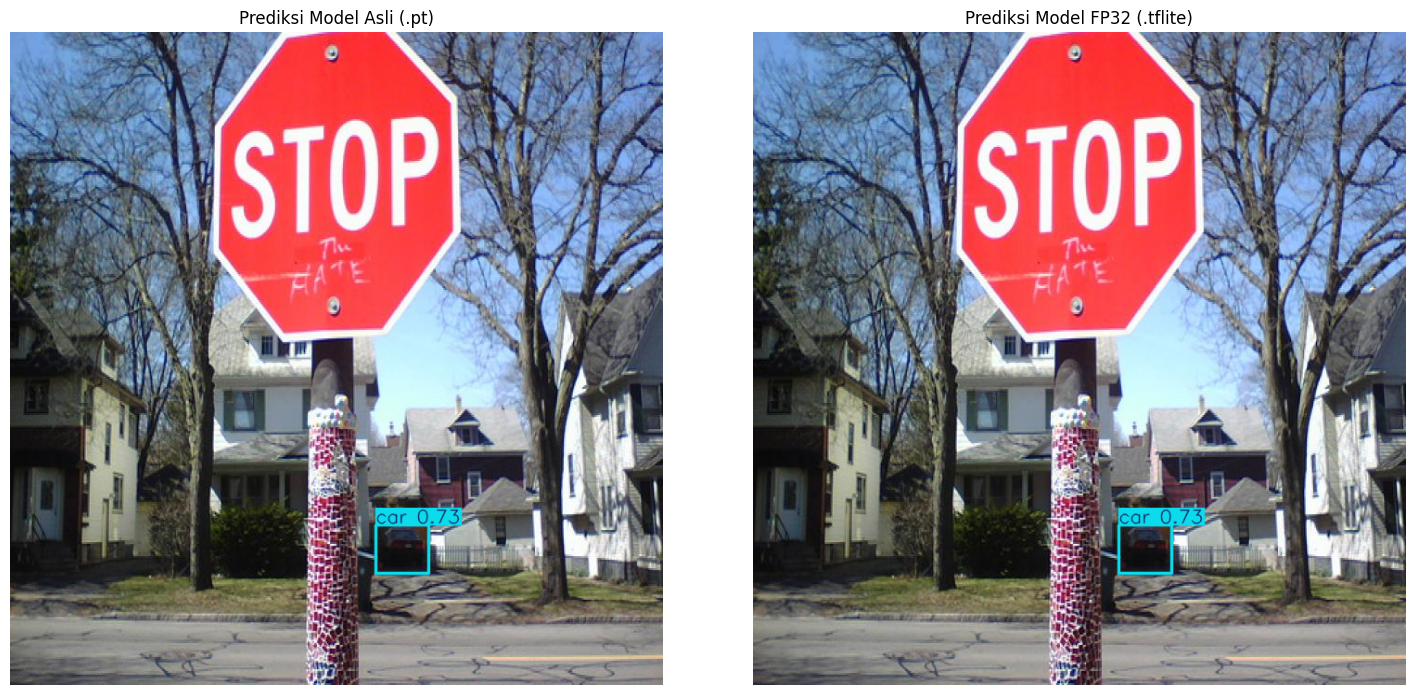

In [12]:
import random
import matplotlib.pyplot as plt
import cv2
import glob

# Pilih satu gambar acak dari dataset test
test_images = glob.glob(f"{master_dir}/test/images/*.jpg")
if test_images:
    test_img = random.choice(test_images)
    print(f"Menguji gambar: {test_img}")
    
    # Prediksi pakai model Asli
    res_pt = model.predict(source=test_img, imgsz=640)
    img_pt = res_pt[0].plot()
    
    # Prediksi pakai model FP32
    res_fp32 = model_fp32.predict(source=test_img, imgsz=640)
    img_fp32 = res_fp32[0].plot()
    
    # Tampilkan perbandingan
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].imshow(cv2.cvtColor(img_pt, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Prediksi Model Asli (.pt)")
    ax[0].axis("off")
    
    ax[1].imshow(cv2.cvtColor(img_fp32, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Prediksi Model FP32 (.tflite)")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada gambar di folder test untuk diprediksi.")


## 8. Visualisasi Grafik Hasil Training
Menampilkan grafik metrik akurasi (*mAP*, *Loss*) dan *Confusion Matrix* yang telah digenerasi oleh YOLO menggunakan `matplotlib` untuk keperluan laporan skripsi.

=== 1. CUSTOM TRAINING DASHBOARD (SEABORN) ===


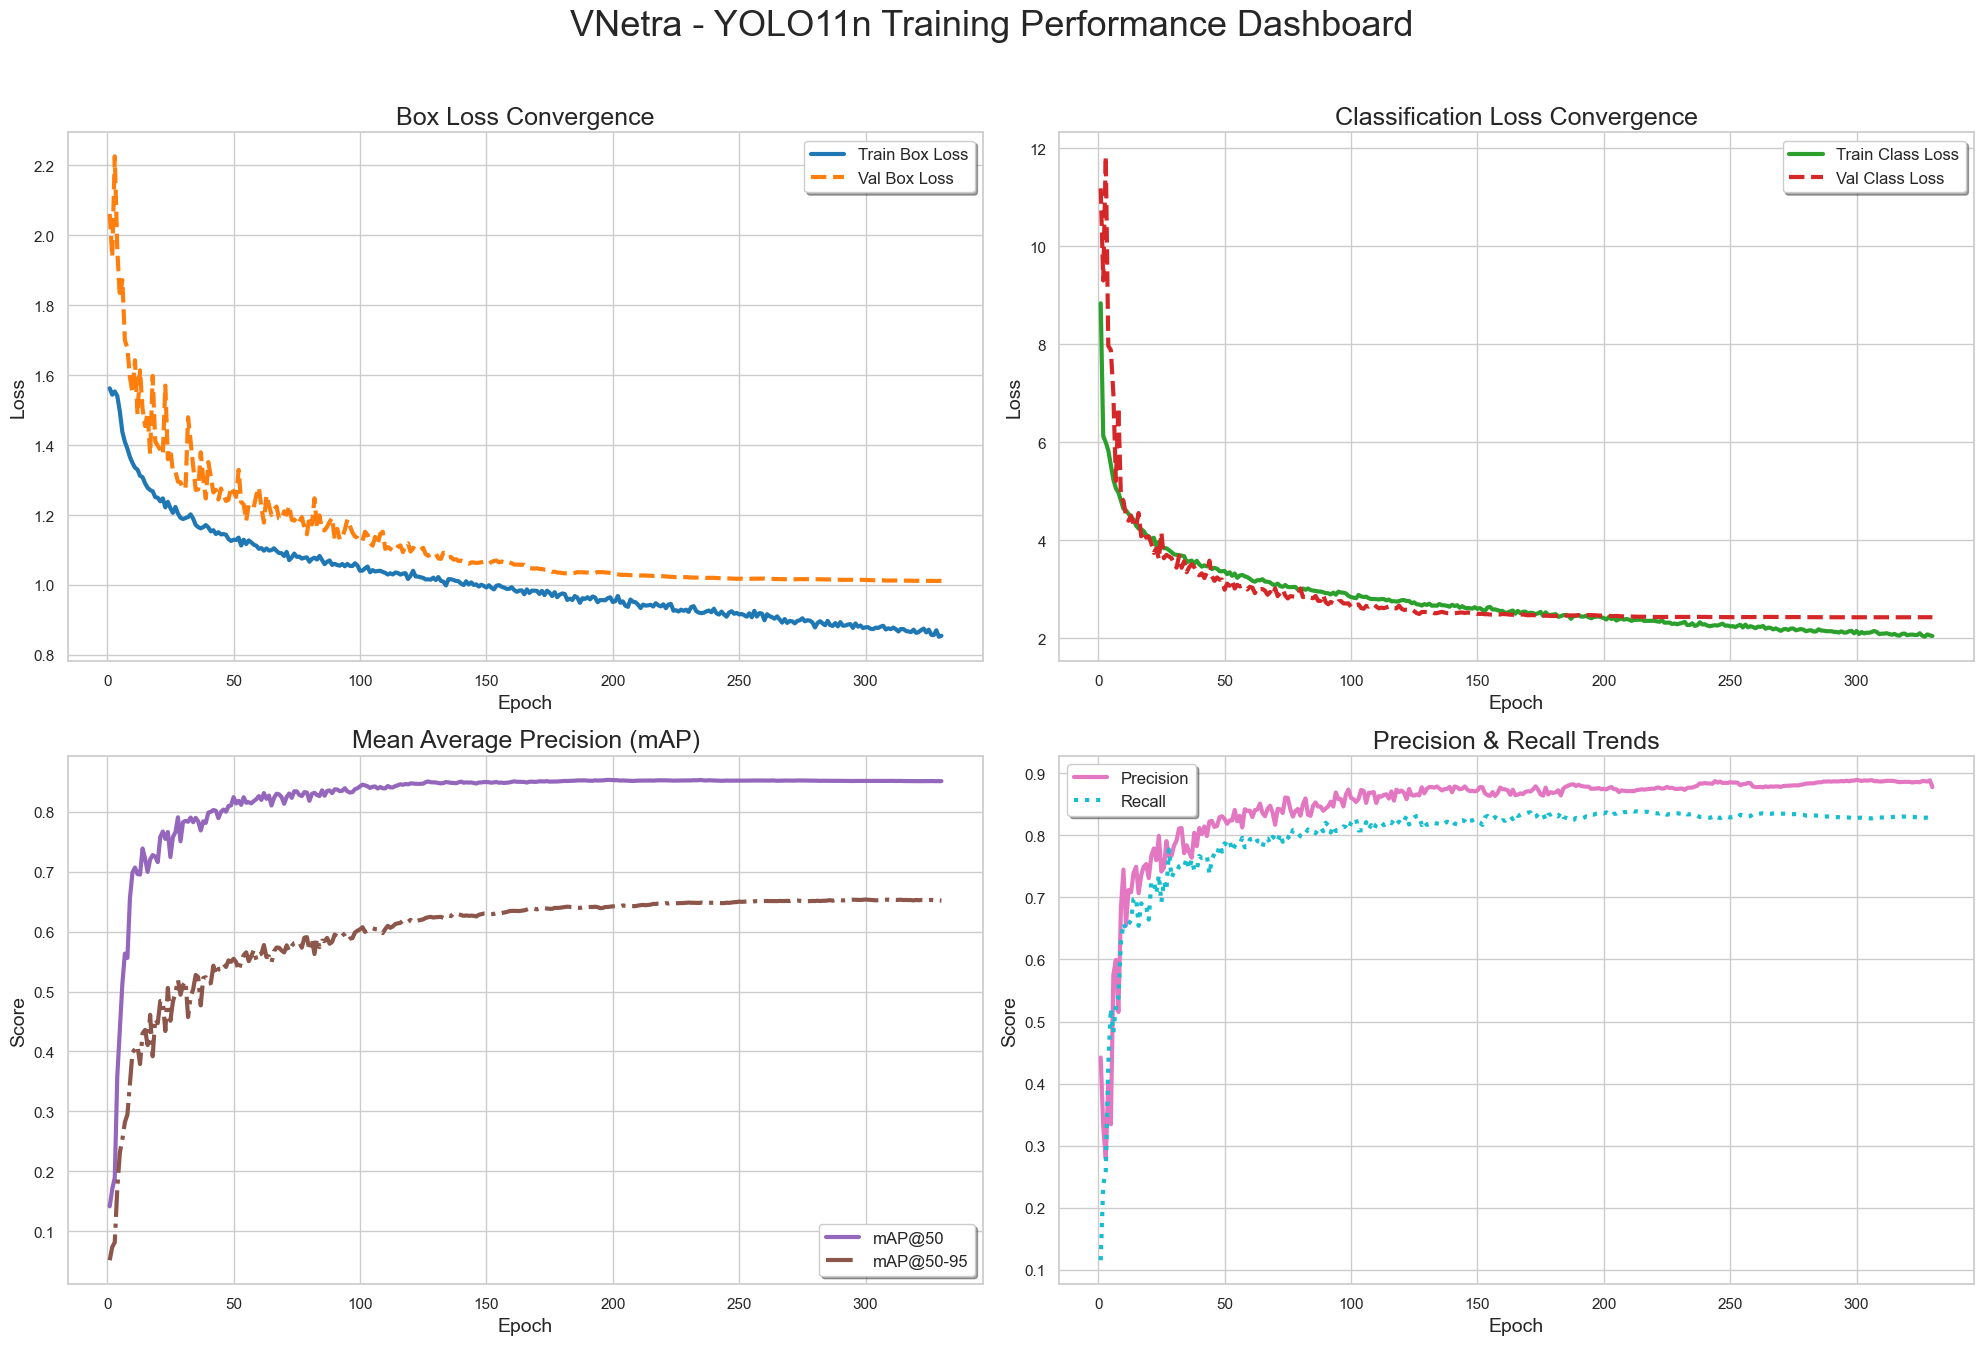


=== 2. CONFUSION MATRIX PROFESIONAL ===


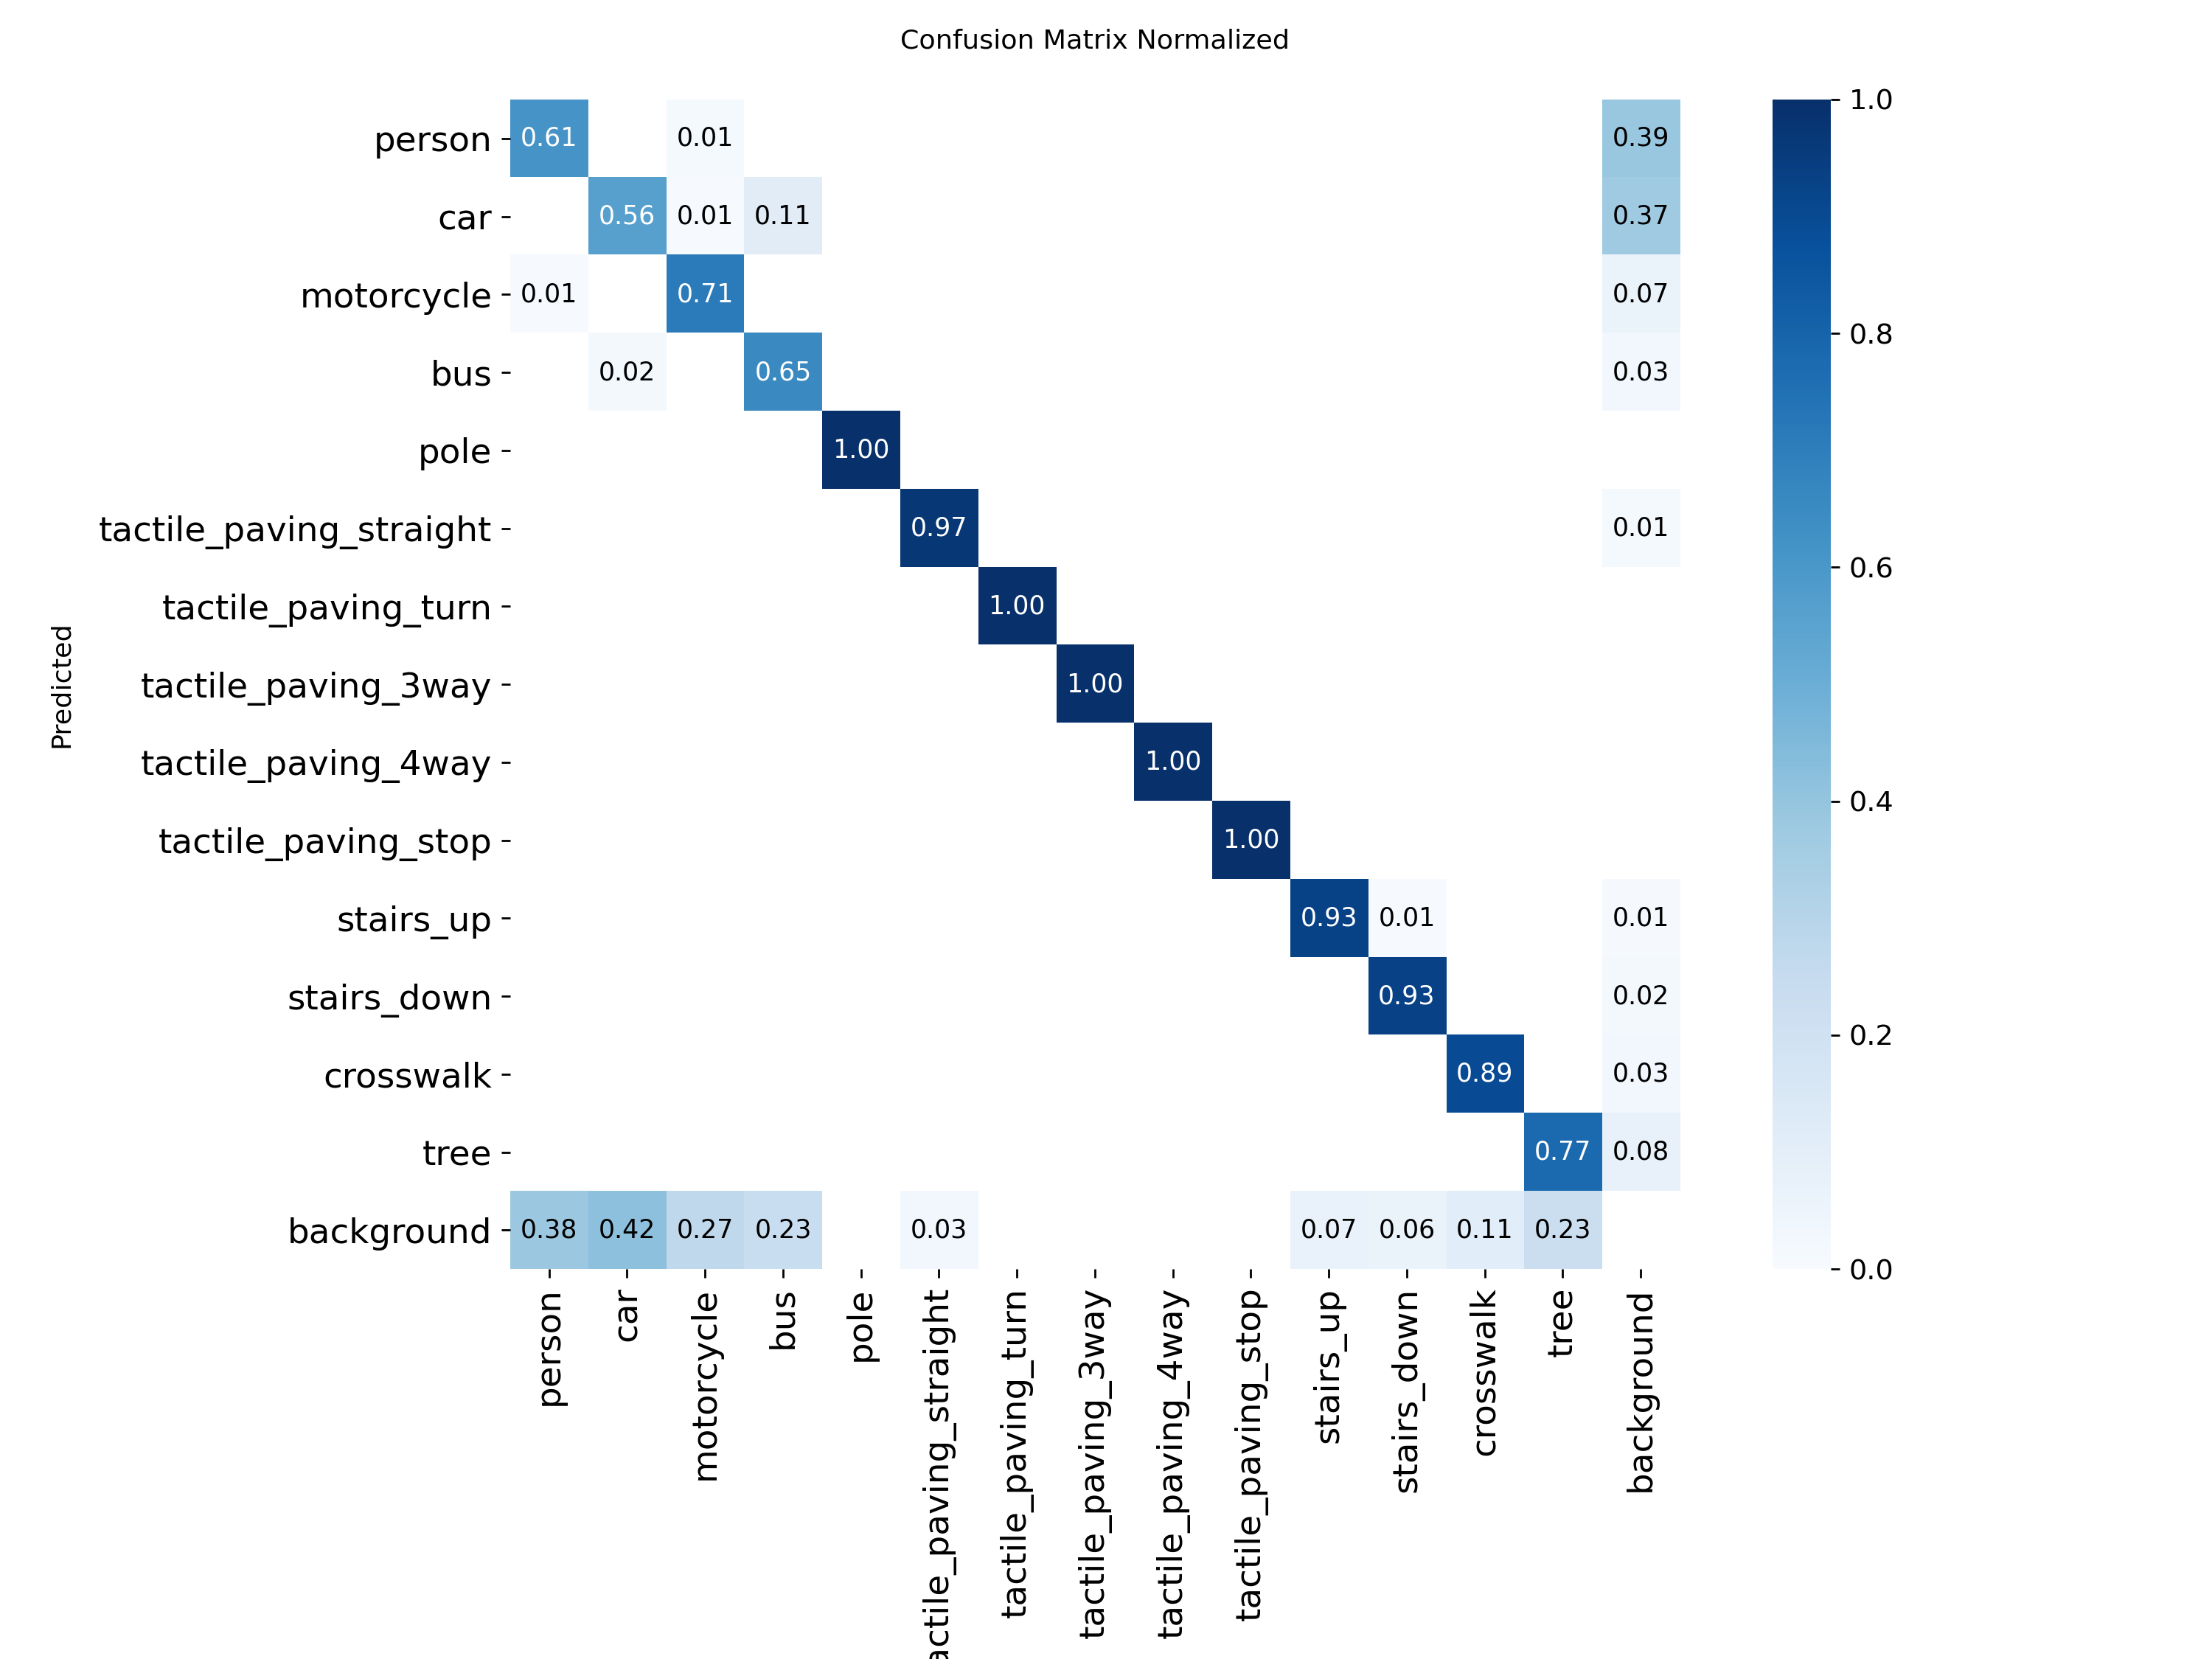


=== 3. KURVA F1-SCORE (Confidence Thresholding) ===


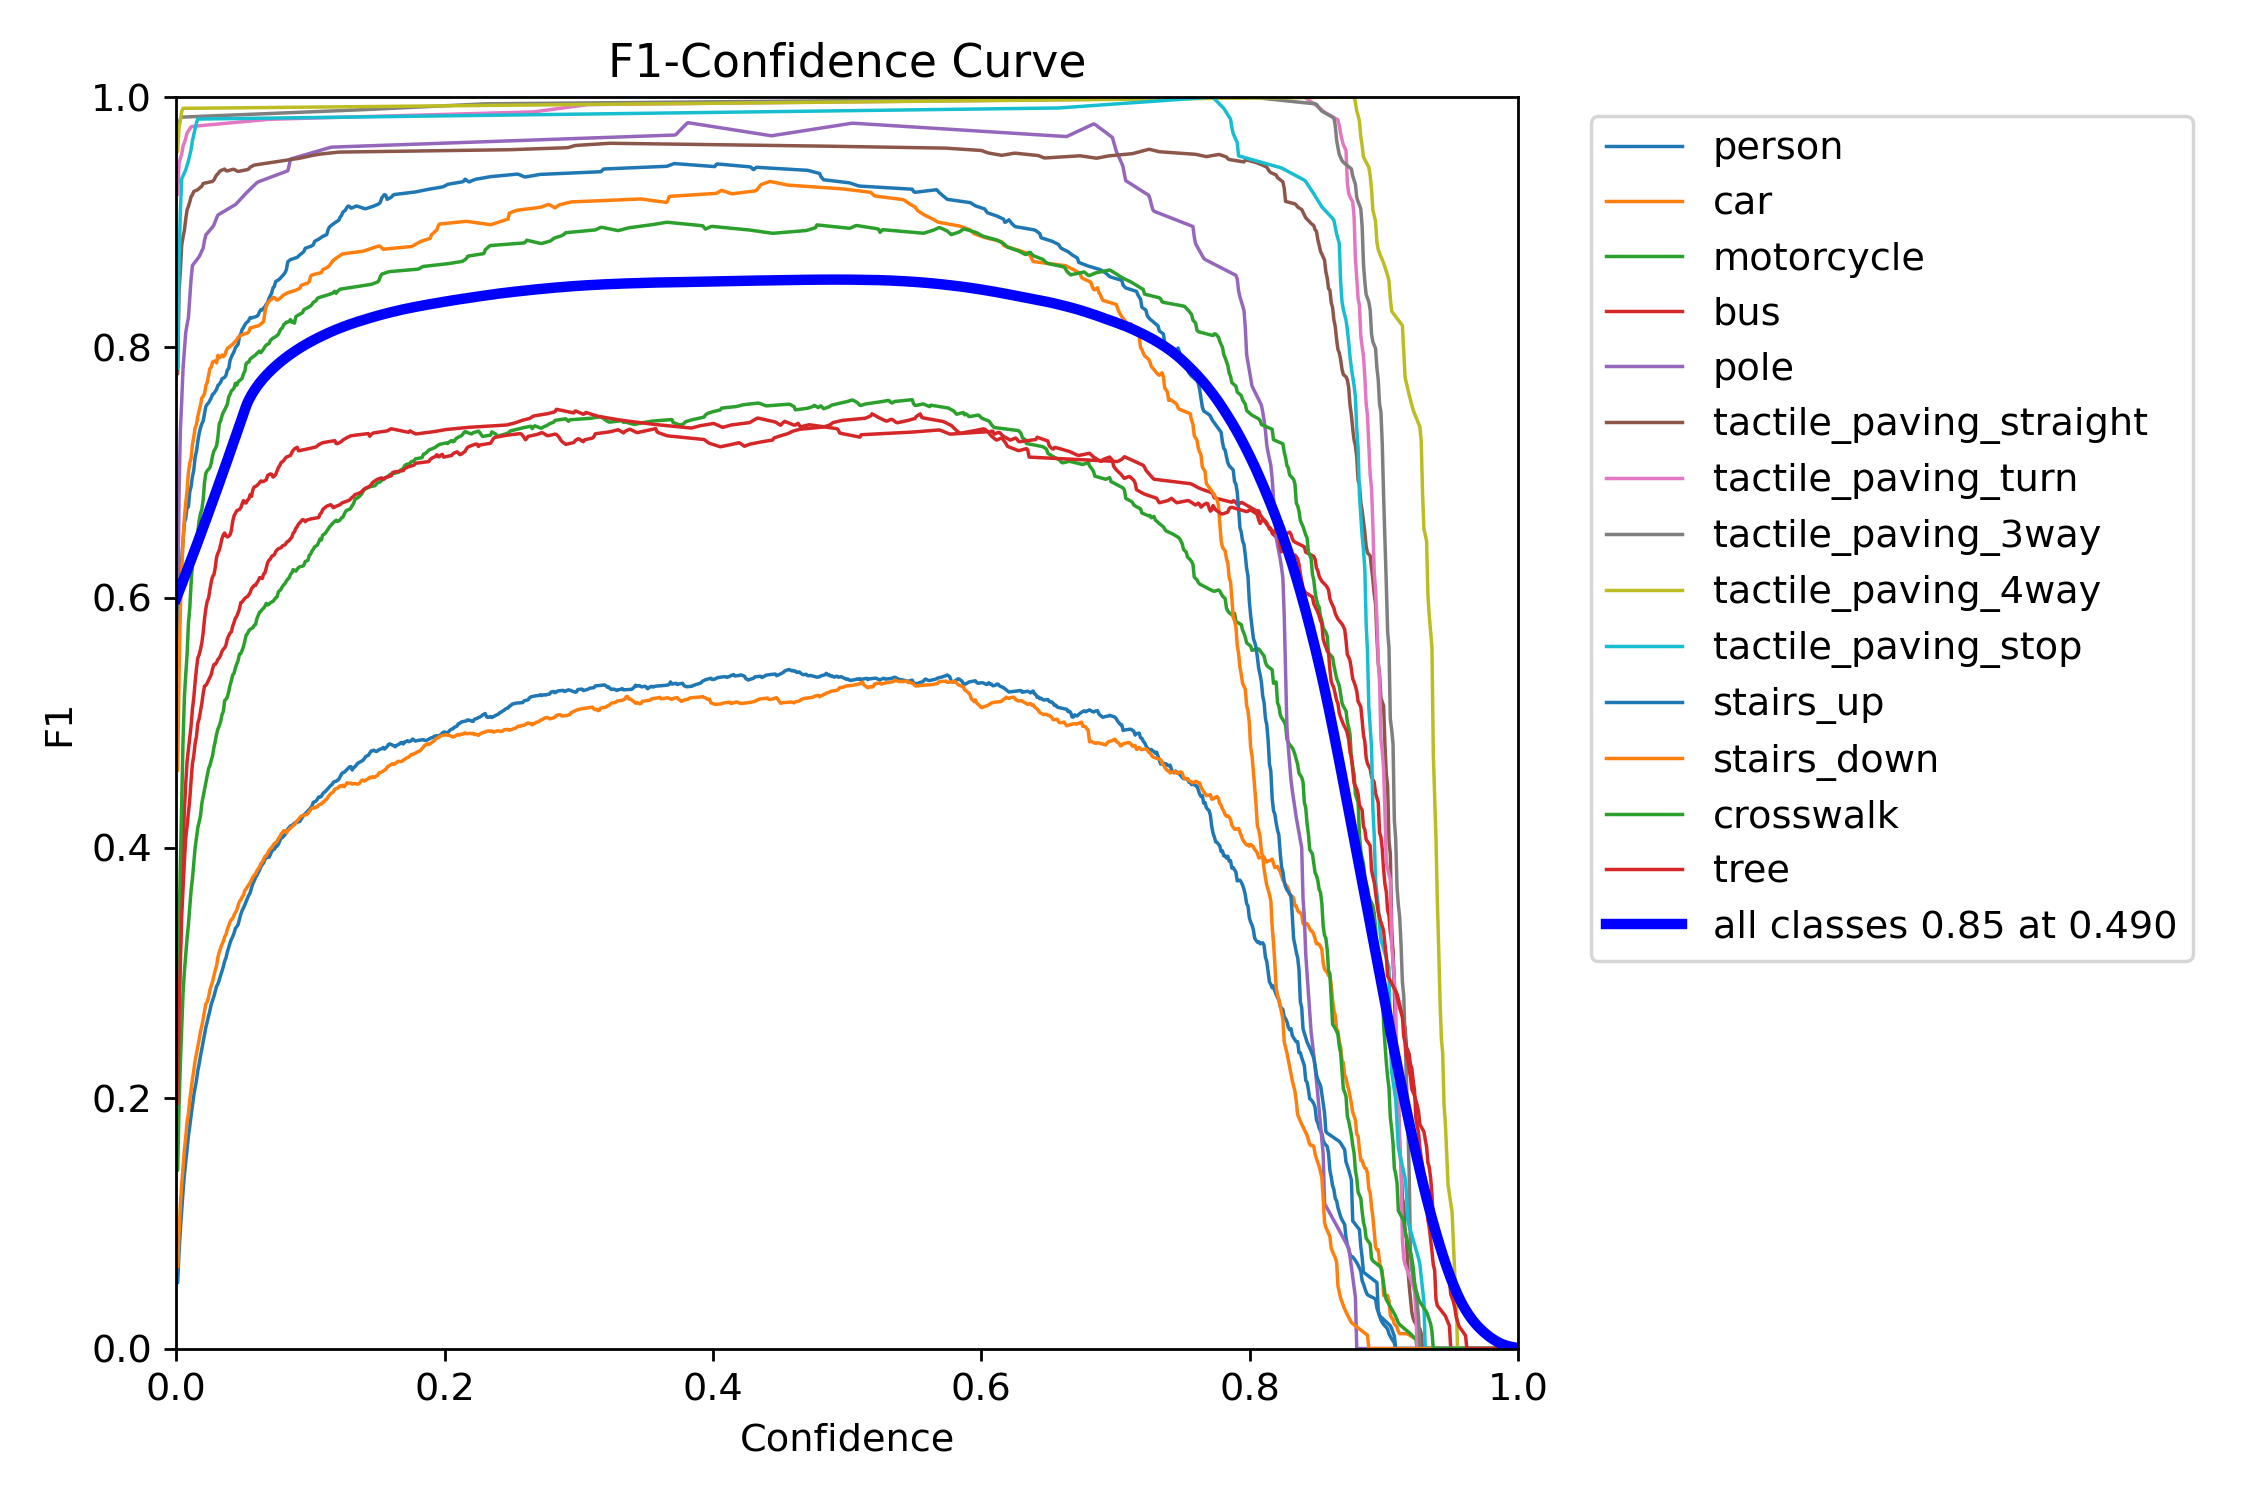


=== 4. VISUALISASI AUGMENTASI MOSAIC PADA DATA TRAINING ===


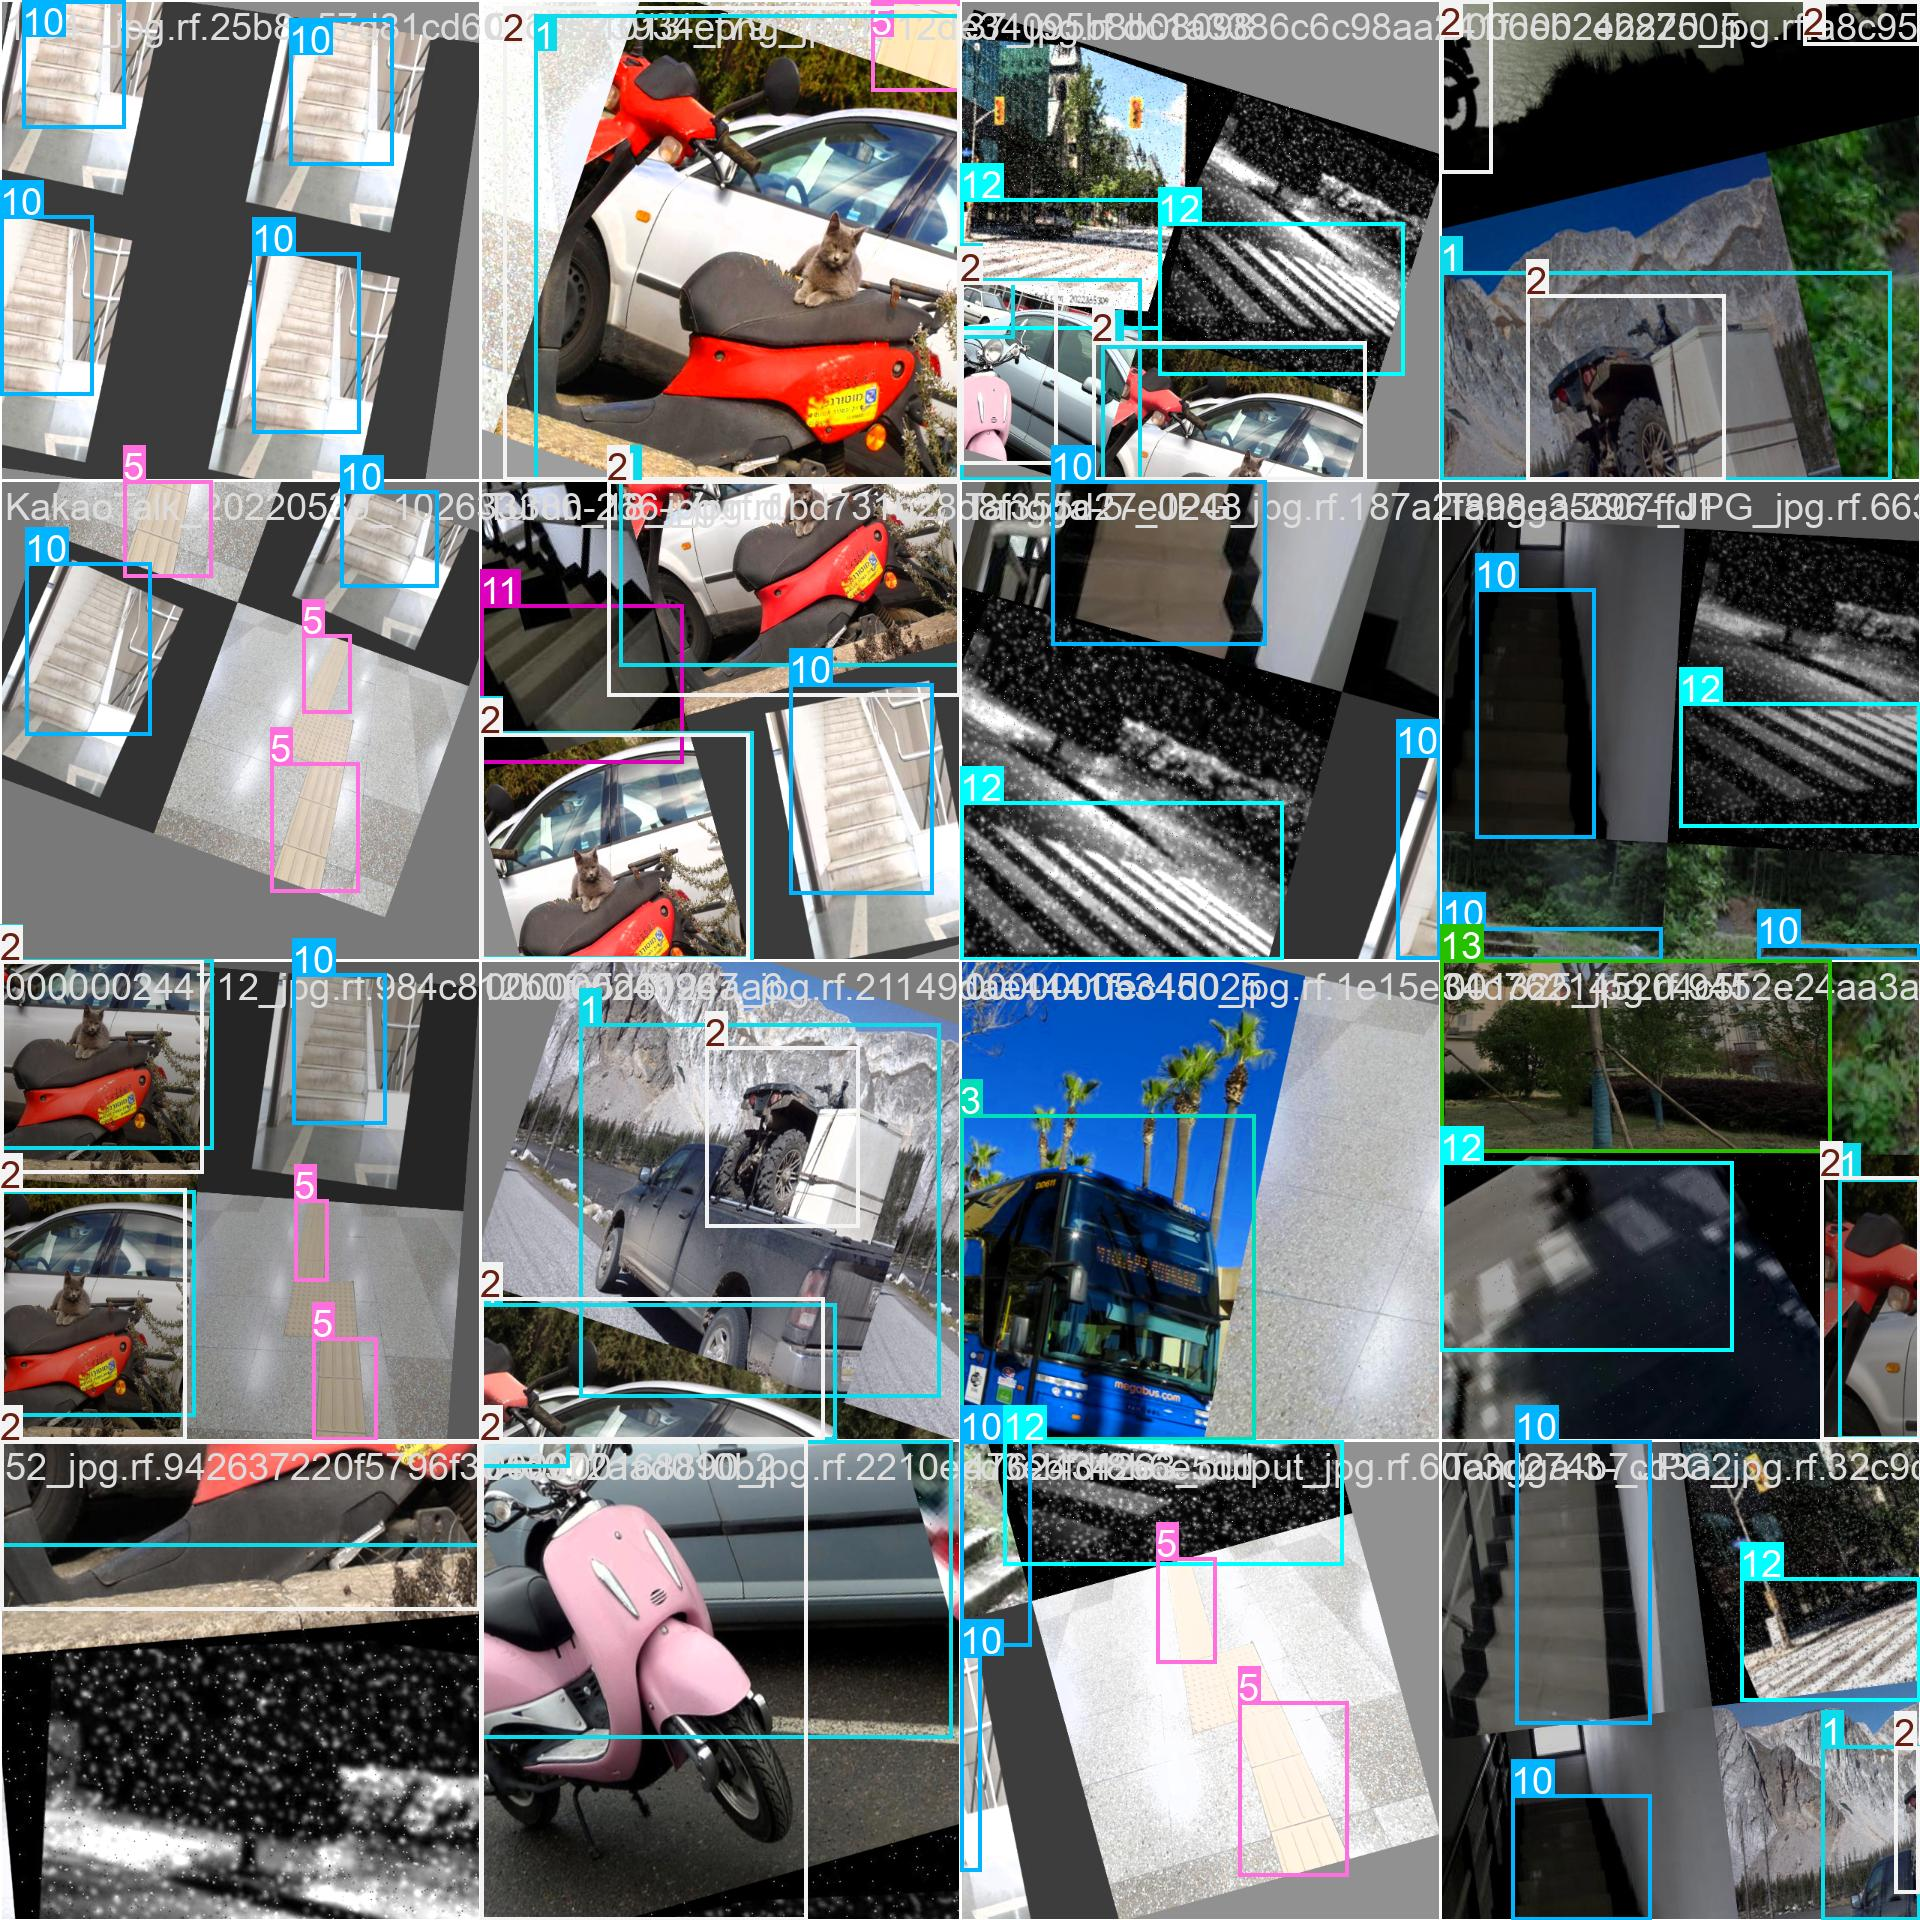


=== 5. SAMPEL PREDIKSI PADA VALIDATION SET ===


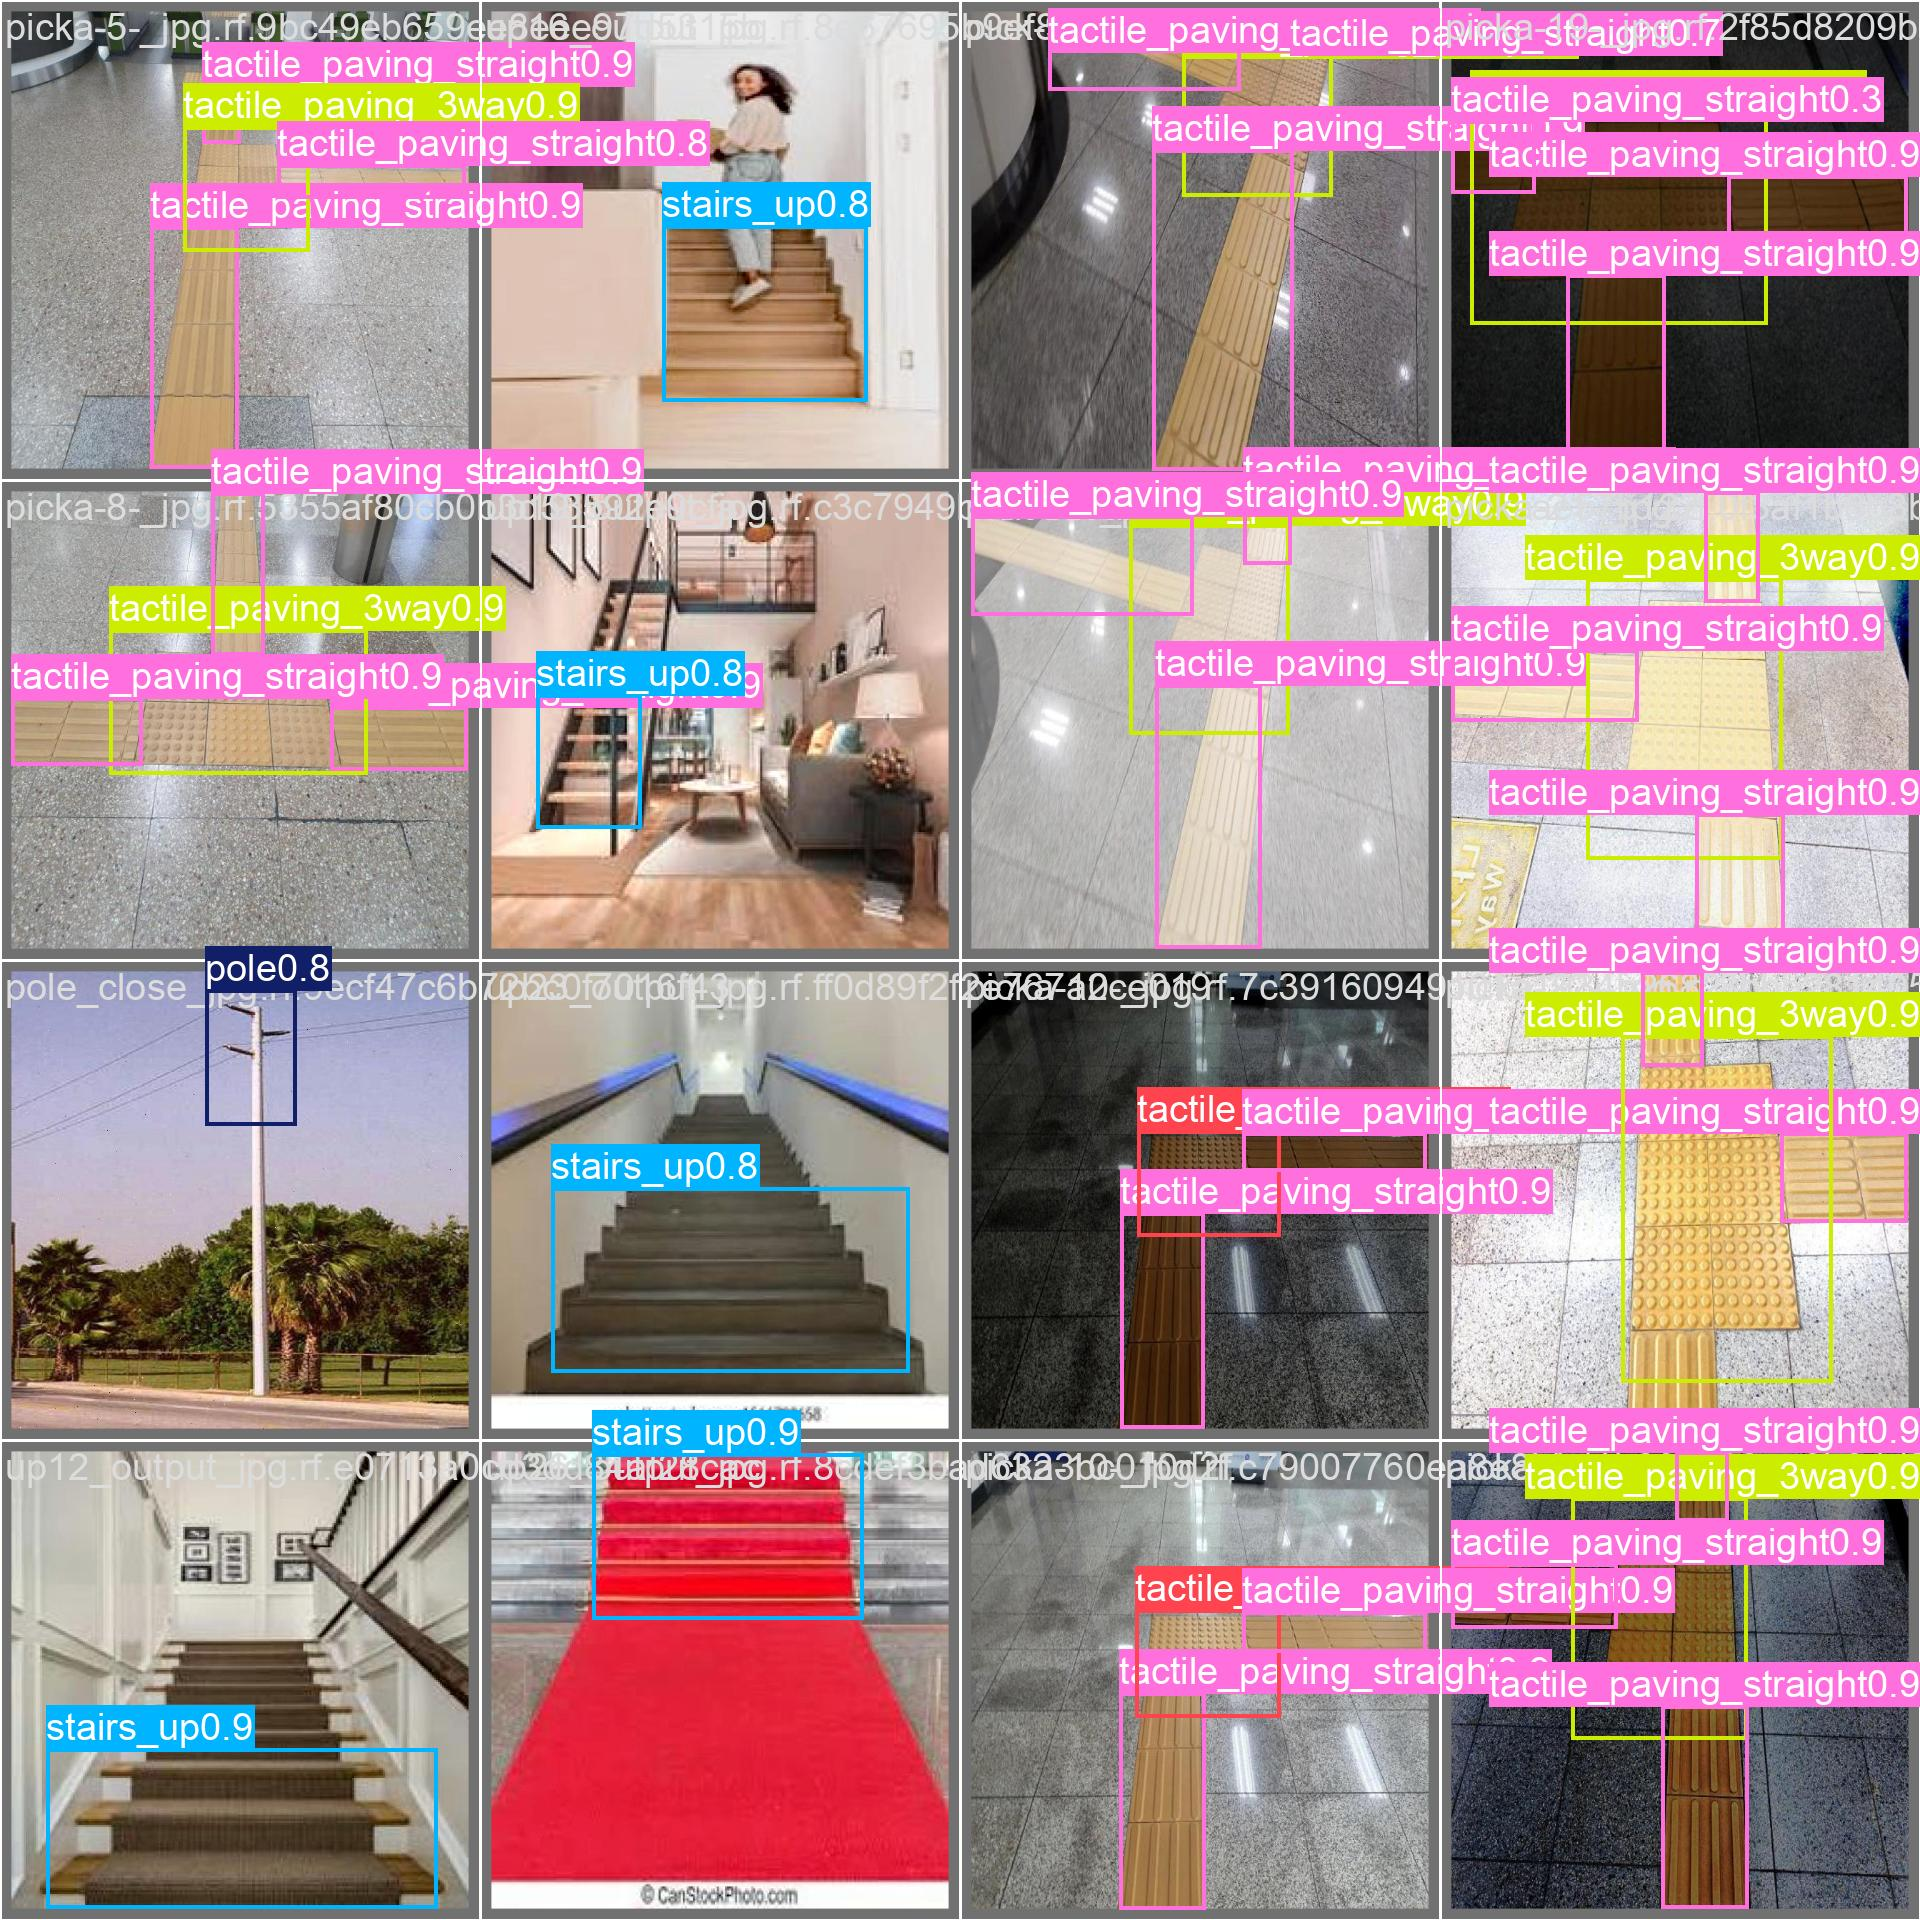

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

base_path = '/kaggle/working/runs/detect/vnetra_training/yolo11n_custom/'
results_path = os.path.join(base_path, 'results.csv')

print('=== 1. CUSTOM TRAINING DASHBOARD (SEABORN) ===')
if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()  # Bersihkan spasi berlebih di nama kolom
    
    sns.set_theme(style='whitegrid', palette='deep')
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('VNetra - YOLO11n Training Performance Dashboard', fontsize=26, fontweight='bold', y=0.96)
    
    # 1. Box Loss Convergence
    sns.lineplot(data=df, x='epoch', y='train/box_loss', ax=axes[0,0], label='Train Box Loss', linewidth=3, color='#1f77b4')
    sns.lineplot(data=df, x='epoch', y='val/box_loss', ax=axes[0,0], label='Val Box Loss', linewidth=3, color='#ff7f0e', linestyle='--')
    axes[0,0].set_title('Box Loss Convergence', fontsize=18, fontweight='bold')
    axes[0,0].set_xlabel('Epoch', fontsize=14)
    axes[0,0].set_ylabel('Loss', fontsize=14)
    axes[0,0].legend(fontsize=12, frameon=True, shadow=True)
    
    # 2. Class Loss Convergence
    sns.lineplot(data=df, x='epoch', y='train/cls_loss', ax=axes[0,1], label='Train Class Loss', linewidth=3, color='#2ca02c')
    sns.lineplot(data=df, x='epoch', y='val/cls_loss', ax=axes[0,1], label='Val Class Loss', linewidth=3, color='#d62728', linestyle='--')
    axes[0,1].set_title('Classification Loss Convergence', fontsize=18, fontweight='bold')
    axes[0,1].set_xlabel('Epoch', fontsize=14)
    axes[0,1].set_ylabel('Loss', fontsize=14)
    axes[0,1].legend(fontsize=12, frameon=True, shadow=True)
    
    # 3. mAP Score Evolution
    sns.lineplot(data=df, x='epoch', y='metrics/mAP50(B)', ax=axes[1,0], label='mAP@50', linewidth=3, color='#9467bd')
    sns.lineplot(data=df, x='epoch', y='metrics/mAP50-95(B)', ax=axes[1,0], label='mAP@50-95', linewidth=3, color='#8c564b', linestyle='-.')
    axes[1,0].set_title('Mean Average Precision (mAP)', fontsize=18, fontweight='bold')
    axes[1,0].set_xlabel('Epoch', fontsize=14)
    axes[1,0].set_ylabel('Score', fontsize=14)
    axes[1,0].legend(fontsize=12, frameon=True, shadow=True)
    
    # 4. Precision & Recall
    sns.lineplot(data=df, x='epoch', y='metrics/precision(B)', ax=axes[1,1], label='Precision', linewidth=3, color='#e377c2')
    sns.lineplot(data=df, x='epoch', y='metrics/recall(B)', ax=axes[1,1], label='Recall', linewidth=3, color='#17becf', linestyle=':')
    axes[1,1].set_title('Precision & Recall Trends', fontsize=18, fontweight='bold')
    axes[1,1].set_xlabel('Epoch', fontsize=14)
    axes[1,1].set_ylabel('Score', fontsize=14)
    axes[1,1].legend(fontsize=12, frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
else:
    print('File results.csv belum ditemukan.')

def display_result(image_path, width=None):
    if os.path.exists(image_path):
        if width:
            display(Image(filename=image_path, width=width))
        else:
            display(Image(filename=image_path))
    else:
        print(f'\u26a0\ufe0f Gambar tidak ditemukan: {os.path.basename(image_path)}')
        print('   (Gambar ini baru akan digenerate oleh YOLO di detik terakhir setelah epoch 50 selesai 100%)')

print('\n=== 2. CONFUSION MATRIX PROFESIONAL ===')
display_result(os.path.join(base_path, 'confusion_matrix_normalized.png'), width=1200)

print('\n=== 3. KURVA F1-SCORE (Confidence Thresholding) ===')
display_result(os.path.join(base_path, 'BoxF1_curve.png'), width=1200)

print('\n=== 4. VISUALISASI AUGMENTASI MOSAIC PADA DATA TRAINING ===')
display_result(os.path.join(base_path, 'train_batch0.jpg'), width=1200)

print('\n=== 5. SAMPEL PREDIKSI PADA VALIDATION SET ===')
display_result(os.path.join(base_path, 'val_batch0_pred.jpg'), width=1200)



## 9. Paketkan Hasil Training (ZIP)
Membungkus seluruh grafik evaluasi, kurva performa, matriks kebingungan (*confusion matrix*), dan file model bobot (`best.pt` & `best_fp32.tflite`) ke dalam satu file ZIP yang sangat praktis untuk Anda unduh (tanpa mengikutkan dataset gambar untuk menghemat kuota).

In [14]:
import os
import zipfile

zip_path = "/kaggle/working/vnetra_training_results.zip"
# Path otomatis mendeteksi folder training YOLO
base_run_dir = "/kaggle/working/runs/detect/vnetra_training"

print("Membuat arsip ZIP untuk hasil training...")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    if os.path.exists(base_run_dir):
        for root, dirs, files in os.walk(base_run_dir):
            for file in files:
                file_path = os.path.join(root, file)
                # Menentukan struktur folder di dalam ZIP
                arcname = os.path.relpath(file_path, "/kaggle/working")
                try:
                    zipf.write(file_path, arcname)
                except Exception as e:
                    print(f"Skip file {file} karena error: {e}")
    else:
        print("⚠️ Peringatan: Folder training YOLO tidak ditemukan!")

if os.path.exists(zip_path):
    size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"✅ Berhasil! Silakan unduh file: {zip_path} ({size_mb:.2f} MB)")
    print("File ini berisi semua model terlatih (.pt & .tflite) beserta grafik evaluasi.")
else:
    print("❌ Gagal membuat file ZIP.")


Membuat arsip ZIP untuk hasil training...
✅ Berhasil! Silakan unduh file: /kaggle/working/vnetra_training_results.zip (331.81 MB)
File ini berisi semua model terlatih (.pt & .tflite) beserta grafik evaluasi.


## 10. Bersihkan Sisa Dataset (Opsional)
Menghapus folder dataset dari `/kaggle/working/` agar **tidak ikut tersimpan** menjadi Output Kaggle. Hal ini akan sangat menghemat kapasitas penyimpanan dan mempercepat proses *Save & Run All*.

In [15]:
import shutil
import os

master_dir = '/kaggle/working/vnetra_master_dataset'

if os.path.exists(master_dir):
    print("🗑️ Menghapus folder dataset dari working directory...")
    try:
        shutil.rmtree(master_dir)
        print("✅ Dataset berhasil dihapus. Output Kaggle Anda kini akan jauh lebih ringan!")
    except Exception as e:
        print(f"❌ Gagal menghapus dataset: {e}")
else:
    print("Dataset sudah tidak ada.")


🗑️ Menghapus folder dataset dari working directory...
✅ Dataset berhasil dihapus. Output Kaggle Anda kini akan jauh lebih ringan!
